In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import LogLocator, ScalarFormatter
import seaborn as sns

# Funktion zum Einlesen und Parsen der .log-Datei
def parse_log_file(log_file):
    try:
        # Öffnen und Lesen der .log-Datei
        with open(log_file, 'r') as file:
            lines = file.readlines()

        # Datenstrukturen zum Speichern der Messdaten
        measurements = {'Step': [], 'Psw_M1': [], 'Psw_M2': [], 'Psw_M3': [], 'Vds_M1': [], 'Vds_M2': [], 'Vds_M3': []}

        # Durch alle Zeilen der Log-Datei iterieren
        for i, line in enumerate(lines):
            # Wenn die Zeile mit "Measurement:" beginnt, analysiere die Messwerte
            if line.startswith("Measurement:"):
                measurement_type = line.split(":")[1].strip()
                
                # Extrahiere die nächsten relevanten Messdaten
                for j in range(i + 1, len(lines)):
                    # Wenn eine neue Messung beginnt, stoppe
                    if lines[j].startswith("Measurement:"):
                        break

                    # Extrahiere die Messwerte und Schritte
                    parts = lines[j].split()
                    
                    # Überprüfe, ob der erste Wert eine Zahl ist (step)
                    if parts and parts[0].isdigit():  # Prüft, ob der erste Teil eine Zahl ist
                        step = int(parts[0])
                    else:
                        continue  # Falls keine Zahl, überspringe diese Zeile

                    # Extrahiere den Wert (zweites Element)
                    if len(parts) > 1:
                        try:
                            value = float(parts[1])  # Versuche, den Wert als float zu konvertieren
                        except ValueError:
                            continue  # Wenn der Wert keine gültige Zahl ist, überspringe die Zeile
                    else:
                        continue  # Falls der Wert fehlt, überspringe die Zeile

                    # Füge die Werte in das Dictionary ein
                    if measurement_type == 'psw_m1':
                        measurements['Step'].append(step)
                        measurements['Psw_M1'].append(value)
                    elif measurement_type == 'psw_m2':
                        measurements['Psw_M2'].append(value)
                    elif measurement_type == 'psw_m3':
                        measurements['Psw_M3'].append(value)
                    
                    # Extrahiere die Vds-Messungen
                    if 'vds_m1' in measurement_type:
                        measurements['Vds_M1'].append(value)
                    elif 'vds_m2' in measurement_type:
                        measurements['Vds_M2'].append(value)
                    elif 'vds_m3' in measurement_type:
                        measurements['Vds_M3'].append(value)

        # Erstelle einen Pandas DataFrame aus den gesammelten Messwerten
        df = pd.DataFrame(measurements)
        return df

    except FileNotFoundError:
        print(f"Fehler: Die Datei {log_file} wurde nicht gefunden.")
    except Exception as e:
        print(f"Ein unerwarteter Fehler ist aufgetreten: {e}")

# Hauptteil des Programms
log_file = "Messprojekt.log"  # Gib hier den Pfad zur Log-Datei an
df = parse_log_file(log_file)

if df is not None:
    # Zeige das Ergebnis
    print(df)

    # Optional: Speichere das Ergebnis als CSV-Datei
    df.to_csv('Messdaten.csv', index=False)


     Step    Psw_M1    Psw_M2    Psw_M3  Vds_M1  Vds_M2  Vds_M3
0       1  0.005309  0.014459  0.006392     5.0     5.0     5.0
1       2  0.046065  0.014432  0.006392    15.0     5.0     5.0
2       3  0.127110  0.014434  0.006392    25.0     5.0     5.0
3       4  0.257866  0.014400  0.006391    35.0     5.0     5.0
4       5  0.331528  0.014448  0.006392    40.0     5.0     5.0
..    ...       ...       ...       ...     ...     ...     ...
120   121  0.002127  0.950635  0.409324     5.0    40.0    40.0
121   122  0.034805  0.950291  0.409319    15.0    40.0    40.0
122   123  0.096427  0.950960  0.409315    25.0    40.0    40.0
123   124  0.178017  0.950639  0.409322    35.0    40.0    40.0
124   125  0.224716  0.950665  0.409330    40.0    40.0    40.0

[125 rows x 7 columns]


C:\Users\Mathias Lampert\AppData\Local\Temp\ipykernel_21568\3094736533.py:29: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  ax = sns.barplot(


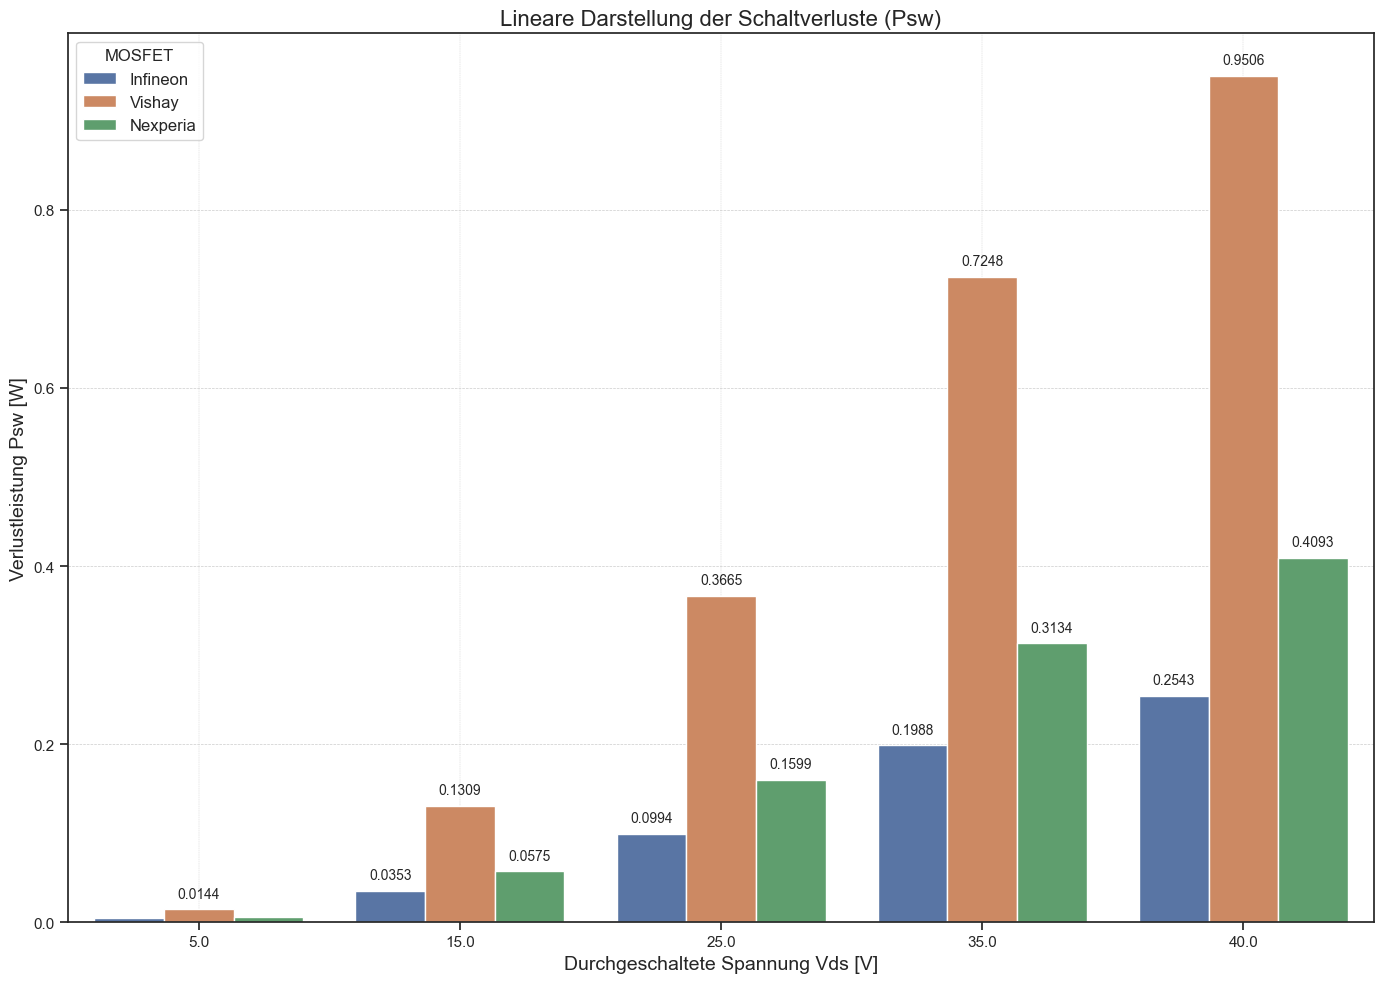

In [5]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# CSV laden
df = pd.read_csv('Messdaten.csv')

# MOSFET-Namen zuweisen
mosfet_labels = ['Infineon'] * len(df) + ['Vishay'] * len(df) + ['Nexperia'] * len(df)

# Daten umformen für barplot
psw_data = pd.DataFrame({
    'MOSFET': mosfet_labels,
    'Vds': df['Vds_M1'].tolist() + df['Vds_M2'].tolist() + df['Vds_M3'].tolist(),
    'Psw': df['Psw_M1'].tolist() + df['Psw_M2'].tolist() + df['Psw_M3'].tolist()
})

# Vds runden für saubere Gruppierung
psw_data['Vds'] = psw_data['Vds'].round(0)

# Kleine Werte optional filtern (z. B. < 0.01 W nicht anzeigen)
# psw_data = psw_data[psw_data['Psw'] >= 0.01]

# Stil
sns.set(style="ticks")

# Plot erzeugen
plt.figure(figsize=(14, 10))
ax = sns.barplot(
    data=psw_data,
    x='Vds',
    y='Psw',
    hue='MOSFET',
    ci=None  # <- verhindert den "Strich" (Standardfehler)
)

# Y-Achse linear
ax.set_yscale('linear')

# Gitterlinien
ax.grid(True, which='both', axis='y', linestyle='--', linewidth=0.5)
ax.grid(True, which='major', axis='x', linestyle='--', linewidth=0.3)

# Balkenwerte annotieren
for container in ax.containers:
    for bar in container:
        height = bar.get_height()
        if height > 0.01:  # Beschriftung nur bei sinnvollen Werten
            ax.text(
                bar.get_x() + bar.get_width() / 2,
                height + max(psw_data['Psw']) * 0.01,
                f"{height:.4f}",
                ha='center',
                va='bottom',
                fontsize=10
            )

# Achsentitel und Legende
plt.title('Lineare Darstellung der Schaltverluste (Psw)', fontsize=16)
plt.xlabel('Durchgeschaltete Spannung Vds [V]', fontsize=14)
plt.ylabel('Verlustleistung Psw [W]', fontsize=14)
plt.legend(title='MOSFET', fontsize=12, title_fontsize=12)

plt.tight_layout()
plt.show()
